In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
pd.options.mode.copy_on_write = True
'''
plot_com_variable(df, comunidades, variables, tipo = 'linea')
plot_todas_comunidades(df, variable, comunidades=None)
plot_dual_axis(df, comunidad, var1, var2, x="año")
correlacion_com_bivariante(df, comunidades, variable1, variable2,alpha = 0.05)
'''
import sys
from pathlib import Path

ROOT_DIR = Path().resolve().parents[1]
sys.path.append(str(ROOT_DIR))

from src import utils as ut

In [2]:
df = pd.read_csv('../../data/processed/dataset_final.csv')
comunidades = list(df.comunidad_autonoma.unique())

In [3]:
def filtrar_columna(df:pd.DataFrame, columna:str):
    '''
    Función para dividir un Dataset, en una lista de Dataset según los valores de una columna.
    '''
    lista_df = []
    lista_valores = df[columna].unique().tolist()
    for valor in lista_valores:
        lista_df.append(df[df[columna] == valor].set_index(columna))
    return lista_df

In [4]:
df_com = filtrar_columna(df, 'comunidad_autonoma')

In [5]:
corr_matrices = {df.index[0]: df.corr() for df in df_com}

## Hipotesis: Incapacidad de hacer frente a gastos económicos imprevistos vs Dificultades para llegar a fin de mes

- **Hipótesis nula (H₀₁):**  
  No existe correlación entre el Incapacidad de hacer frente a gastos económicos imprevistos y el porcentaje de población con dificultad para llegar a fin de mes en una comunidad autónoma a lo largo del tiempo.

- **Hipótesis alternativa (H₁₁):**  
  Existe una correlación entre la incapacidad de hacer frente a gastos económicos imprevistos y la dificultad para llegar a fin de mes.

In [11]:
for comunidad, datos in corr_matrices.items():
    print(comunidad, '||', datos.loc['inc_gastos_imprevistos', 'dificultad_fin_mes'])

Andalucía || 0.880456432690358
Aragón || 0.5273058120009407
Asturias || 0.09883126000766104
Balears || 0.5314339137201584
Canarias || 0.828041745170985
Cantabria || 0.34292449868006236
Castilla - La Mancha || 0.36654710510970295
Castilla Y León || 0.49774159502247306
Cataluña || 0.6917929132588149
Ceuta || 0.4321081781768041
Comunitat Valenciana || 0.7973846716279227
Extremadura || -0.03741153301846906
Galicia || 0.8063572815458133
Madrid || 0.8607178193477342
Melilla || 0.4014743423095999
Murcia || 0.7986214361987759
Navarra || 0.5668342412410371
País Vasco || 0.5478003345805621
Rioja || 0.7954126869693681


In [7]:
ut.correlacion_com_bivariante(df, comunidades, 'inc_gastos_imprevistos', 'dificultad_fin_mes',alpha = 0.05)

Coeficiente de correlación de Spearman entre inc_gastos_imprevistos y dificultad_fin_mes

Comunidades con correlacion positiva y sus coeficientes (pval < 0.05 y coef > 0):
 ['Andalucía', 'Aragón', 'Canarias', 'Cataluña', 'Ceuta', 'Comunitat Valenciana', 'Galicia', 'Madrid', 'Murcia', 'País Vasco', 'Rioja']
 [0.903, 0.645, 0.798, 0.705, 0.569, 0.779, 0.785, 0.886, 0.836, 0.581, 0.767]


Comunidades con correlacion negativa y sus coeficientes (pval < 0.05 y coef < 0):
 []
 []


Comunidades sin correlacion y sus coeficientes (pval < 0.05 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.05):
 ['Asturias', 'Balears', 'Cantabria', 'Castilla - La Mancha', 'Castilla Y León', 'Extremadura', 'Melilla', 'Navarra']
 [0.876, 0.098, 0.134, 0.169, 0.051, 0.899, 0.106, 0.067]


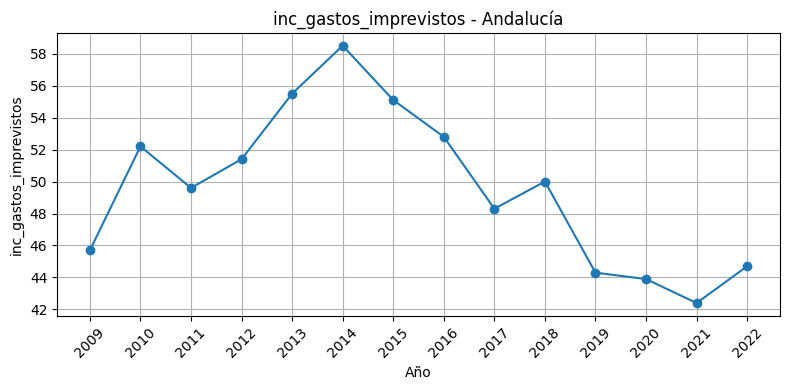

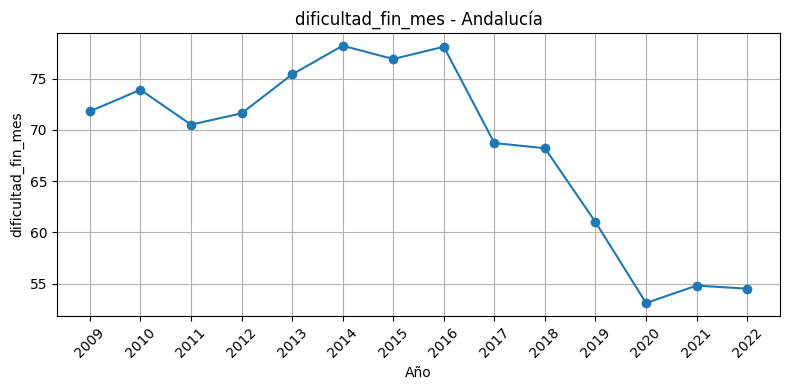

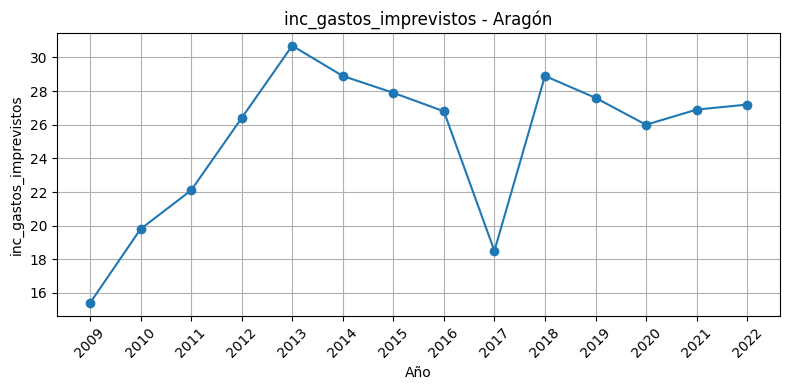

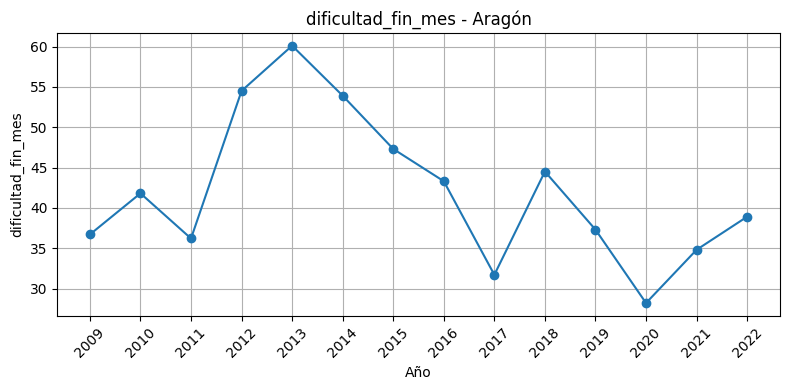

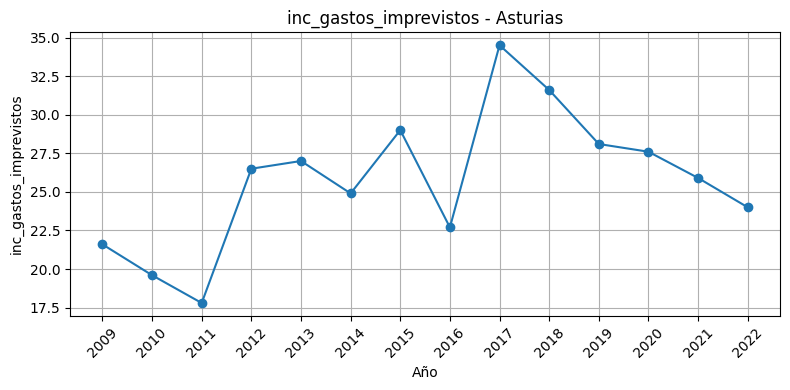

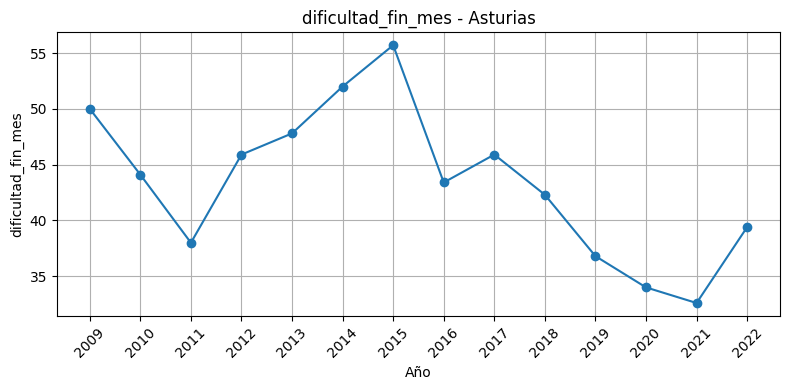

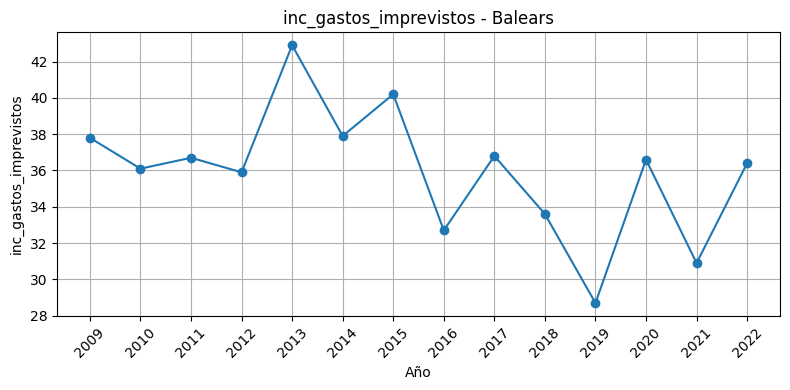

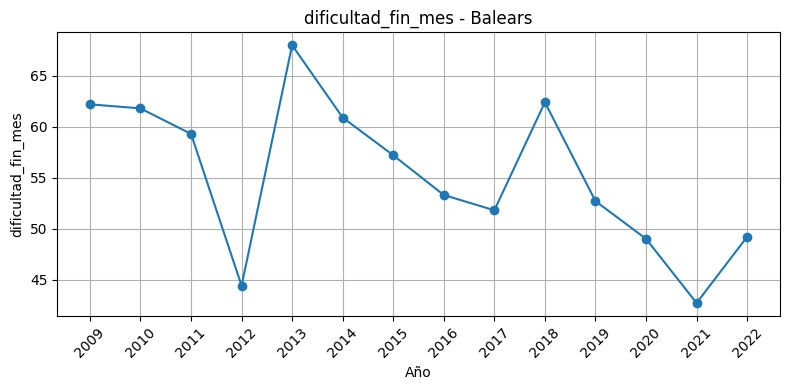

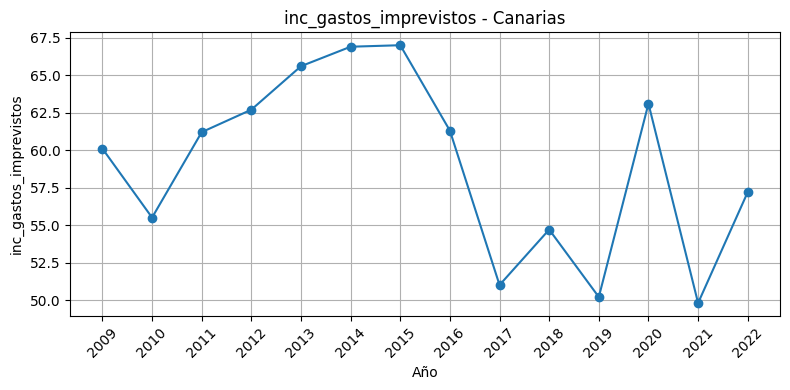

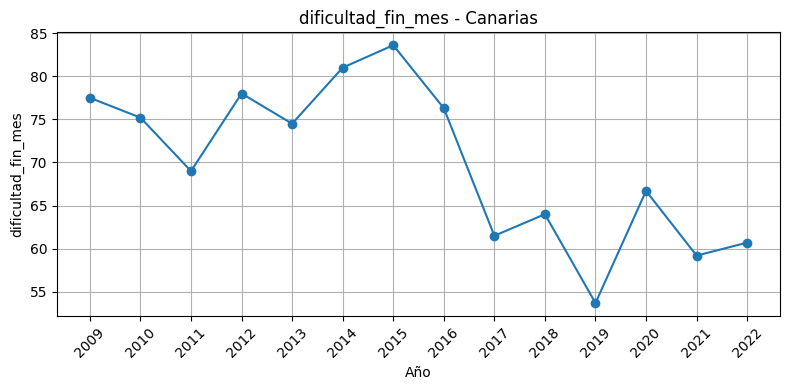

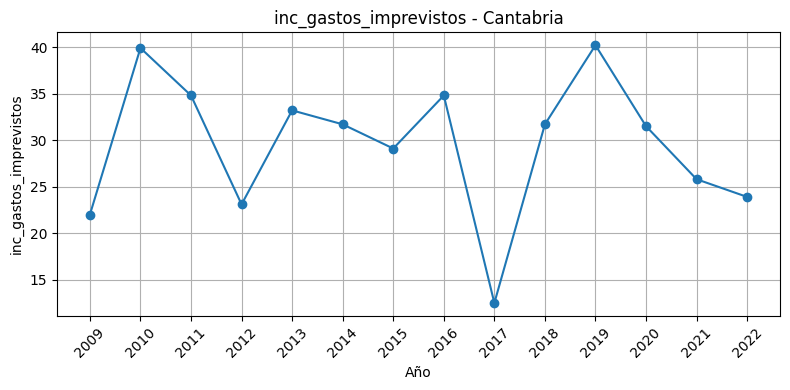

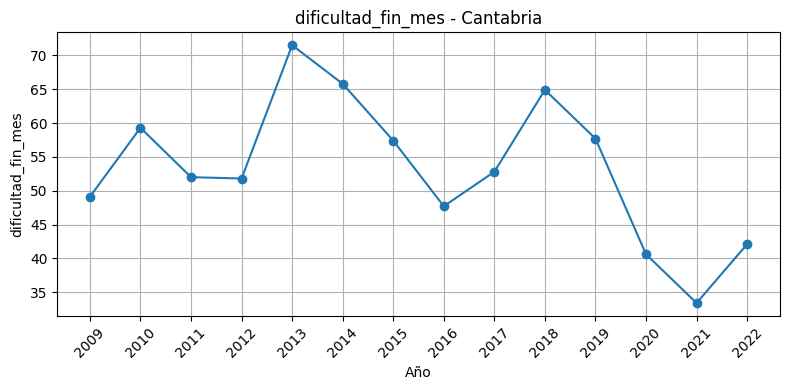

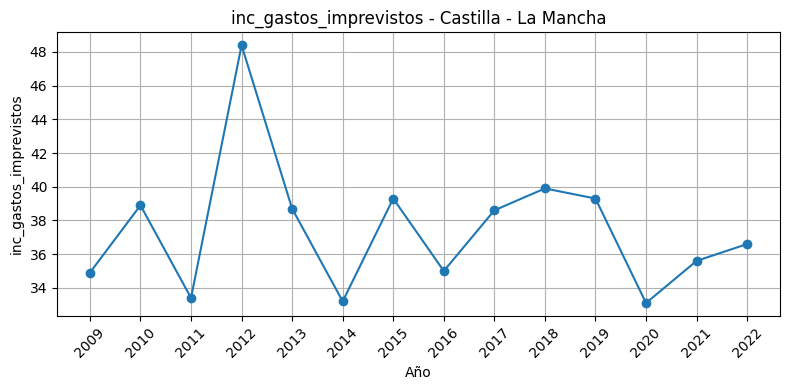

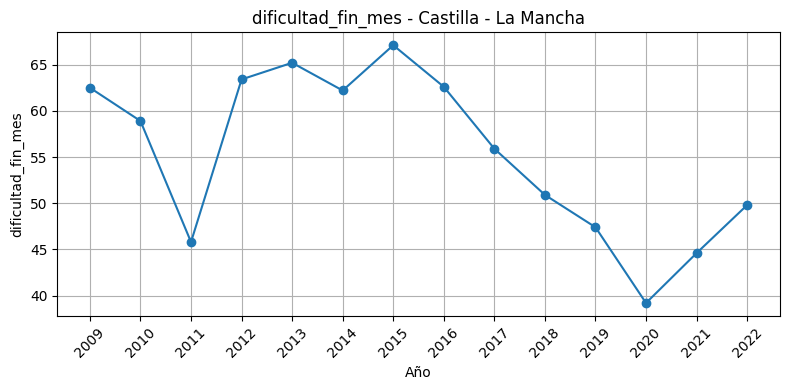

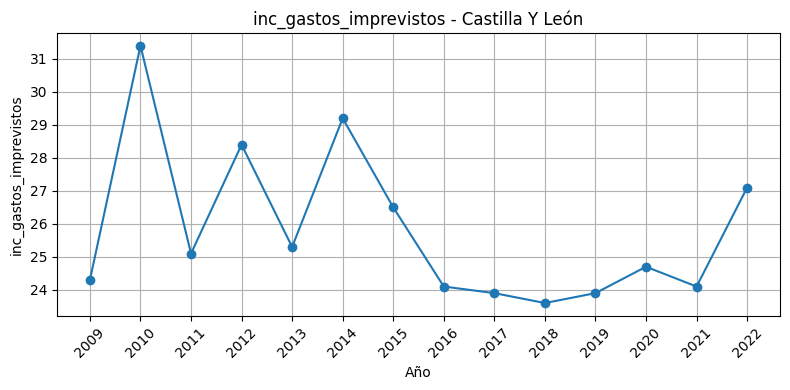

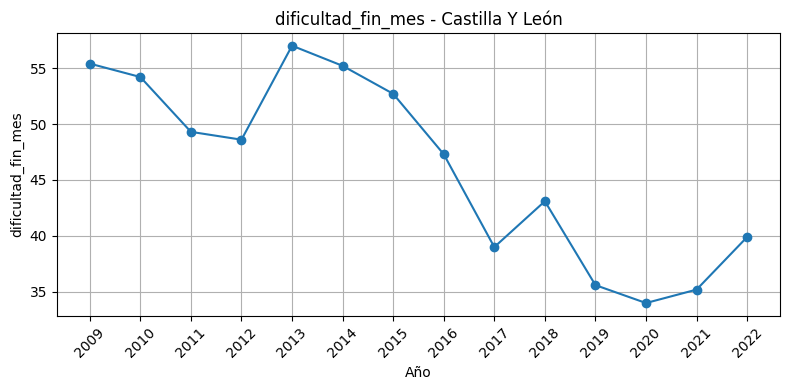

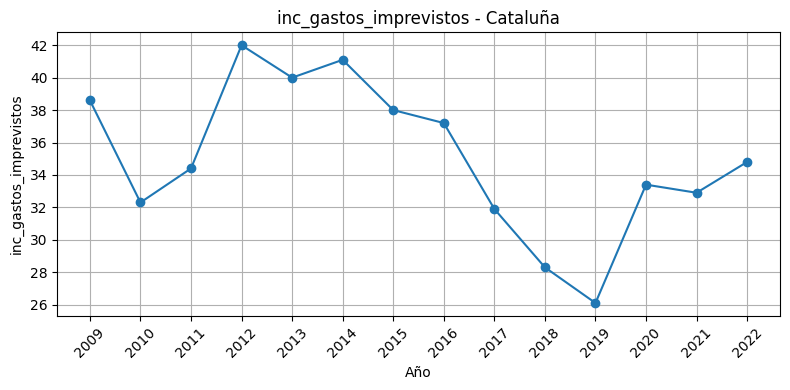

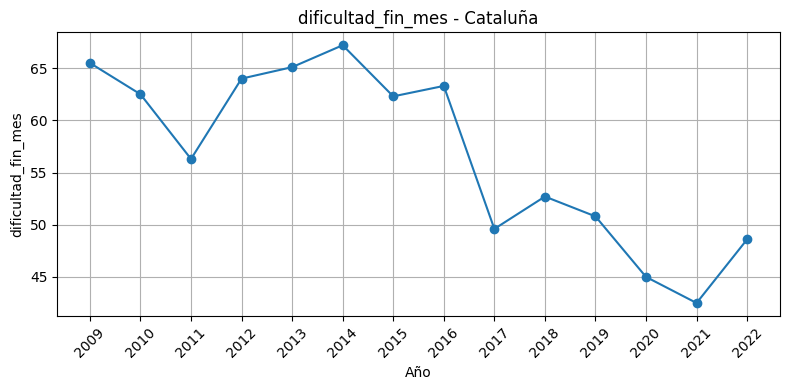

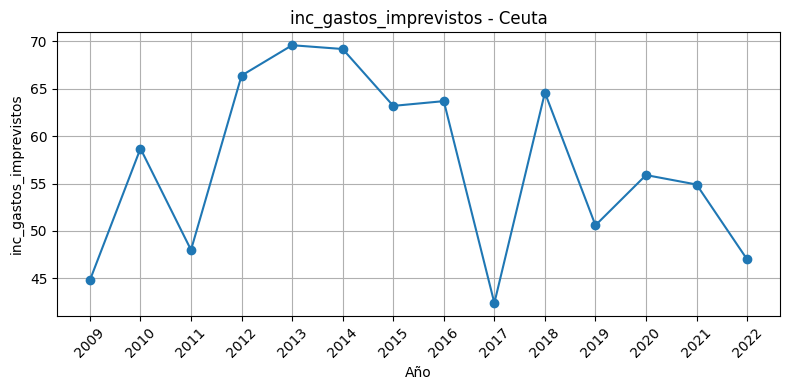

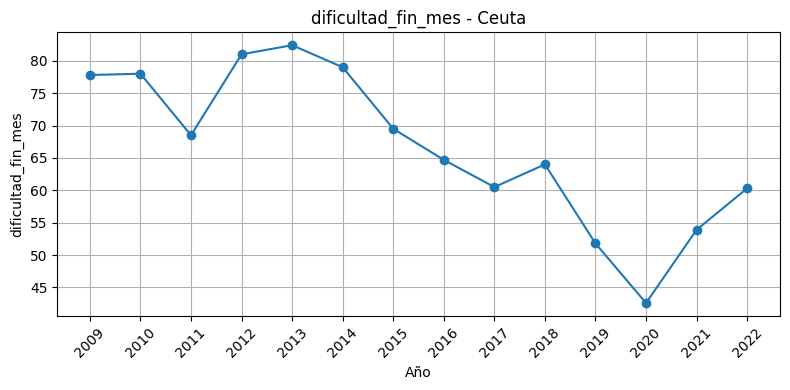

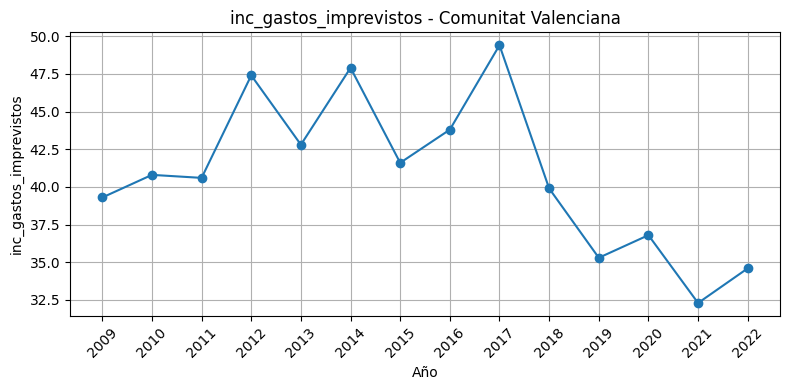

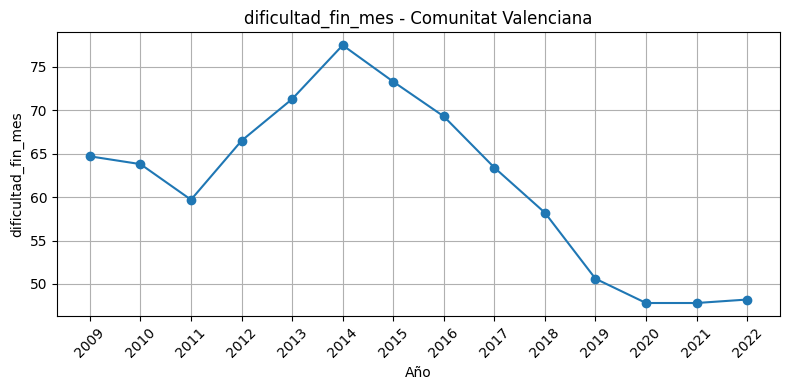

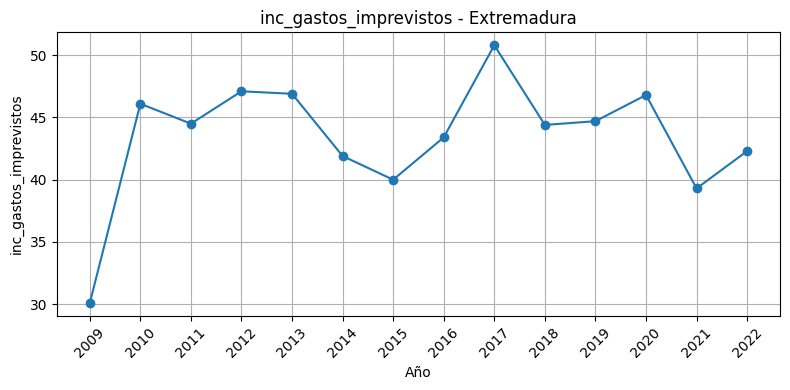

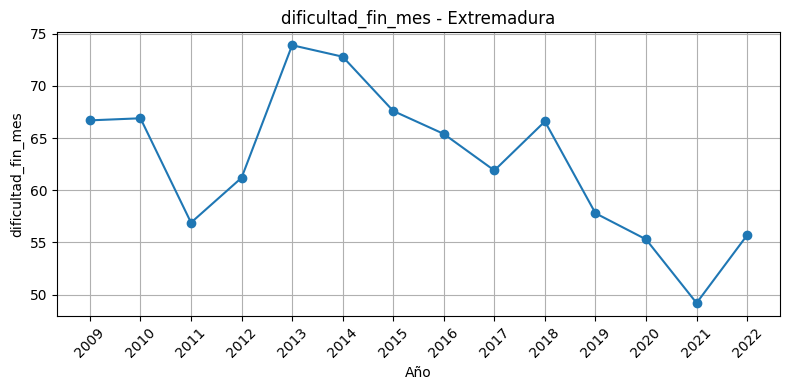

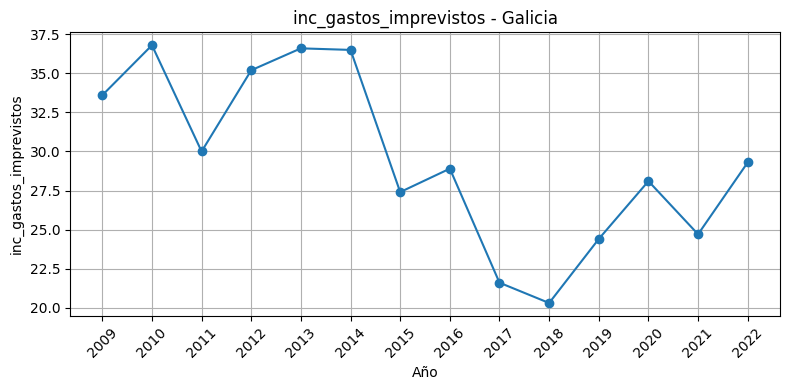

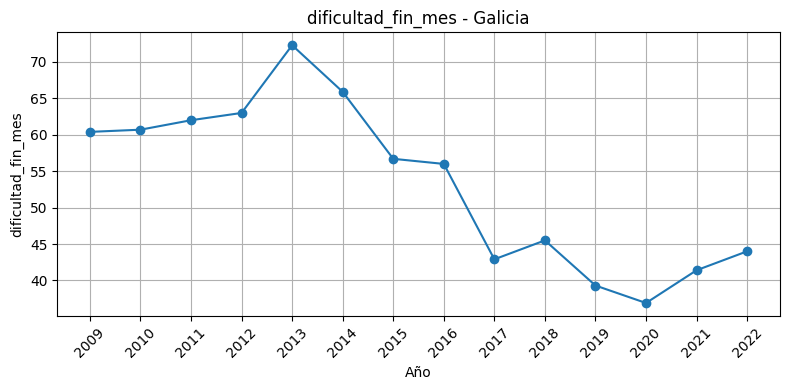

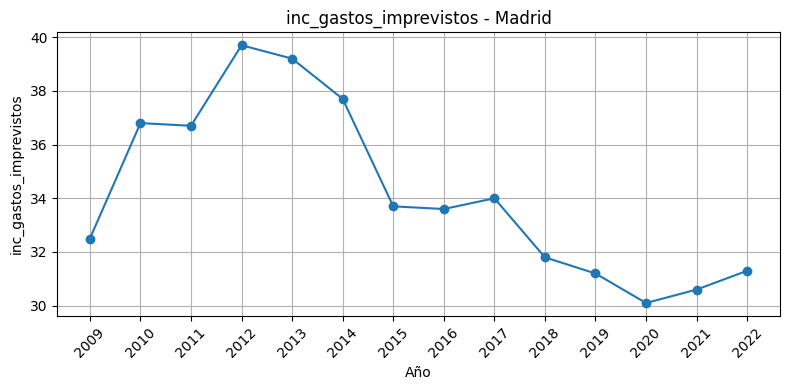

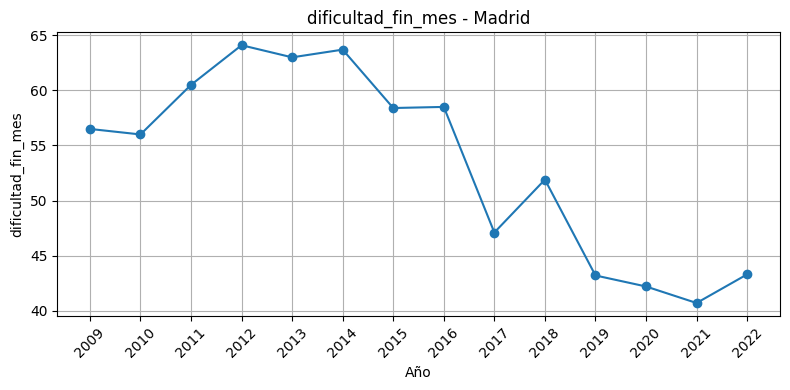

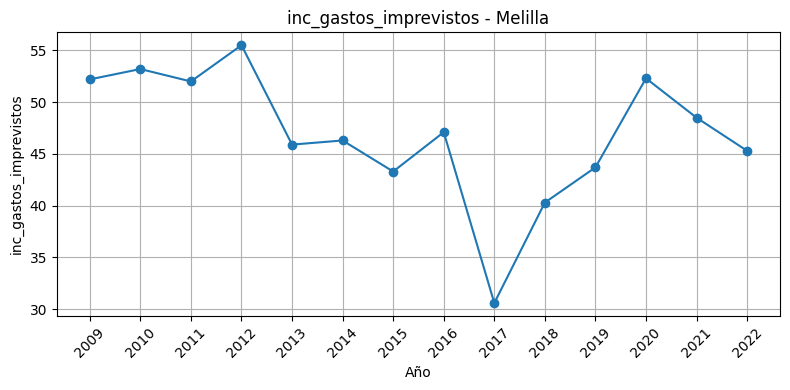

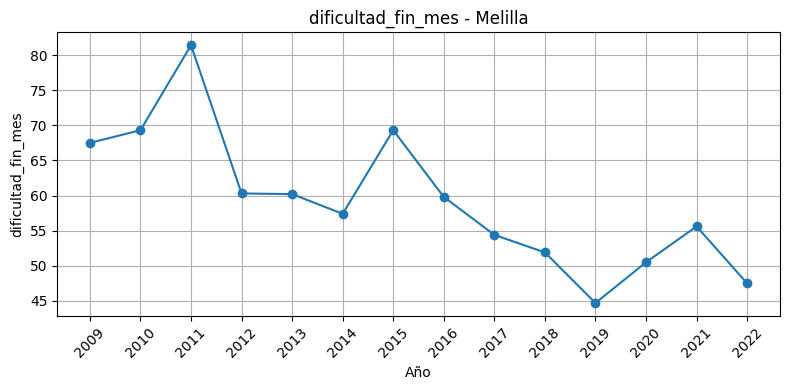

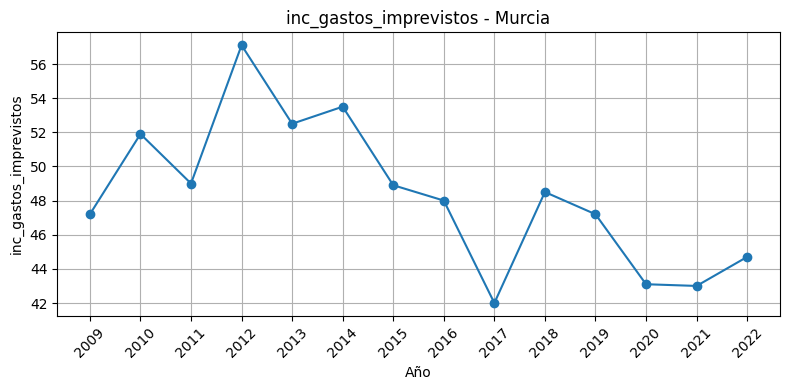

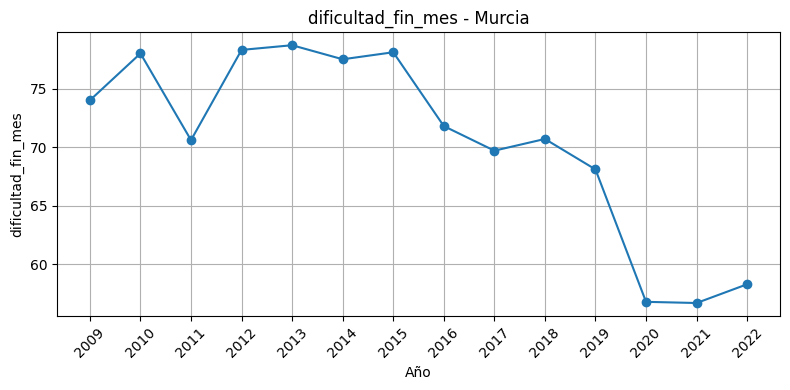

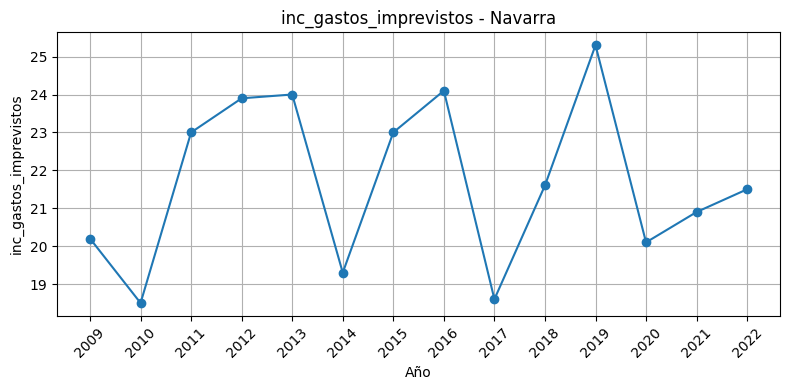

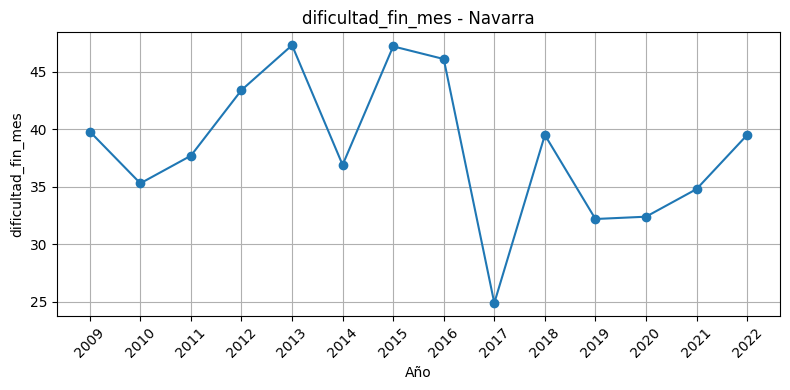

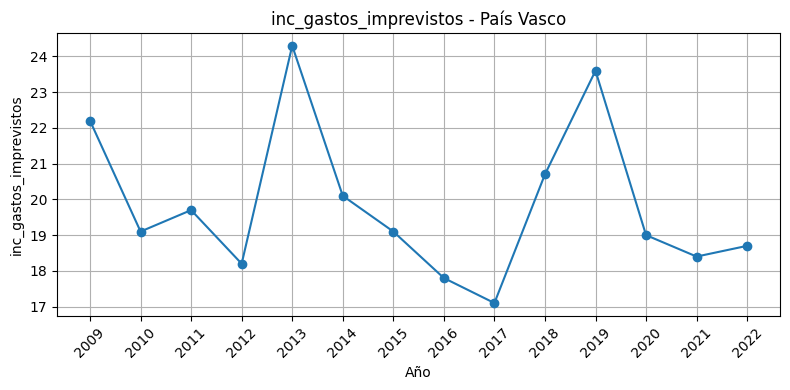

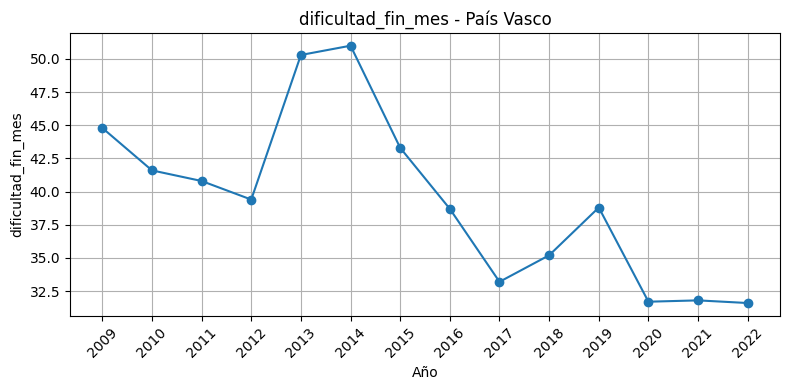

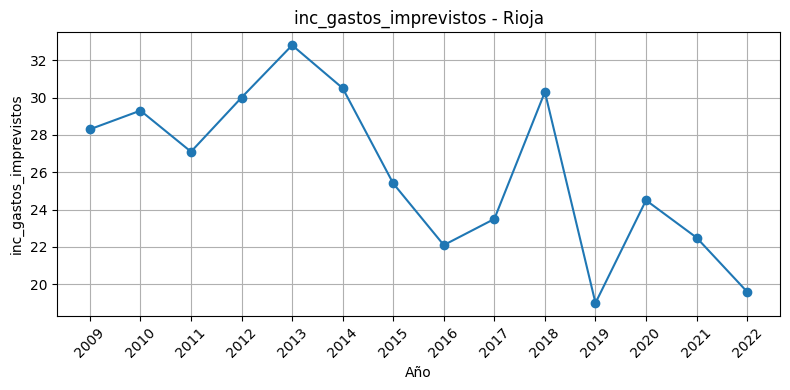

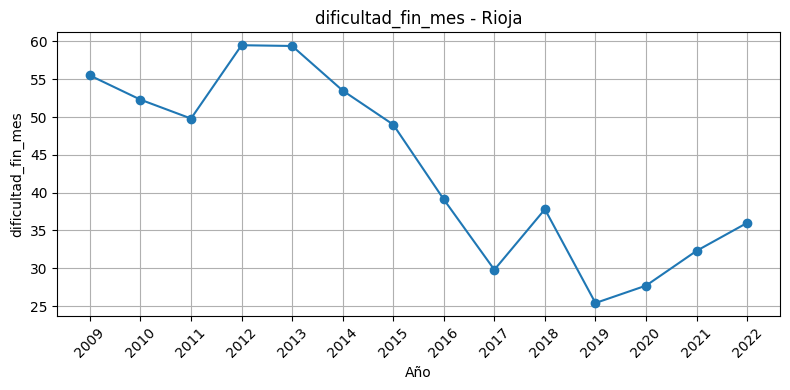

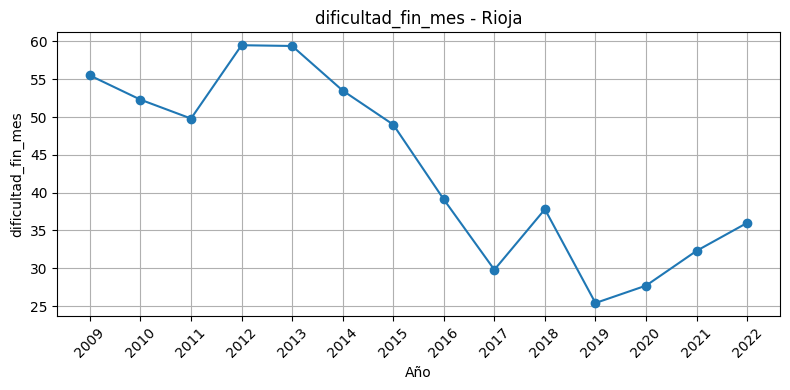

In [8]:
ut.plot_com_variable(df, comunidades, ['inc_gastos_imprevistos', 'dificultad_fin_mes'], tipo = 'linea')

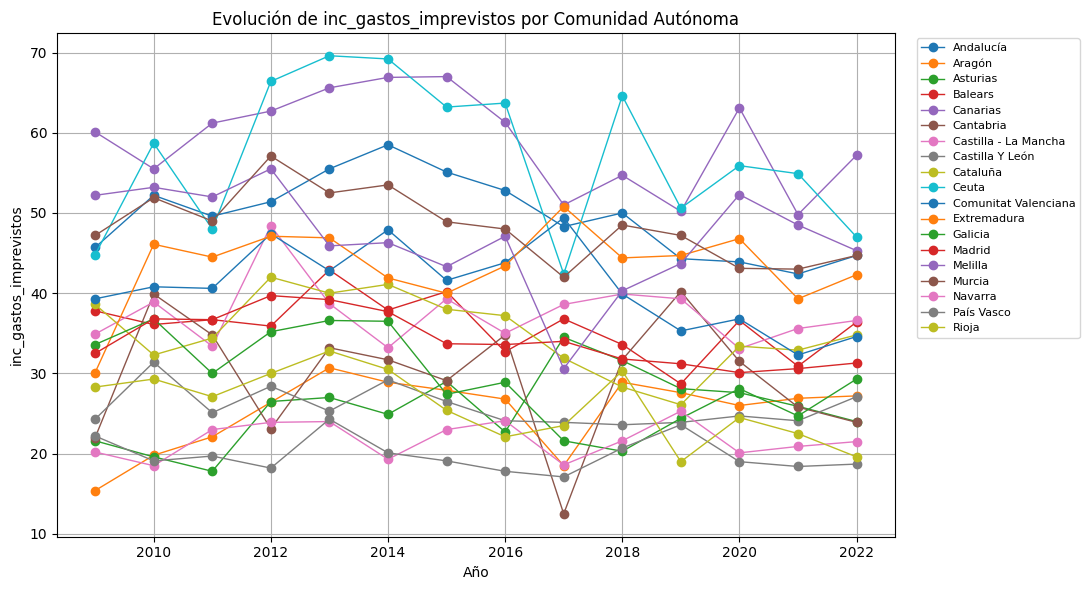

In [12]:
fig = ut.plot_todas_comunidades(df, 'inc_gastos_imprevistos', comunidades=None)

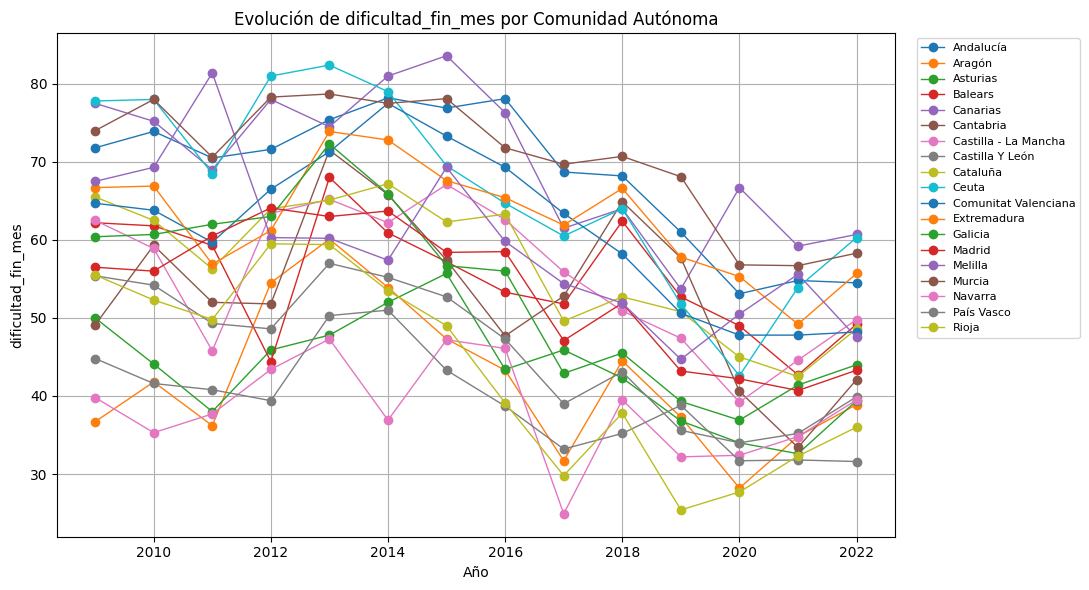

In [13]:
fig = ut.plot_todas_comunidades(df, 'dificultad_fin_mes', comunidades=None)

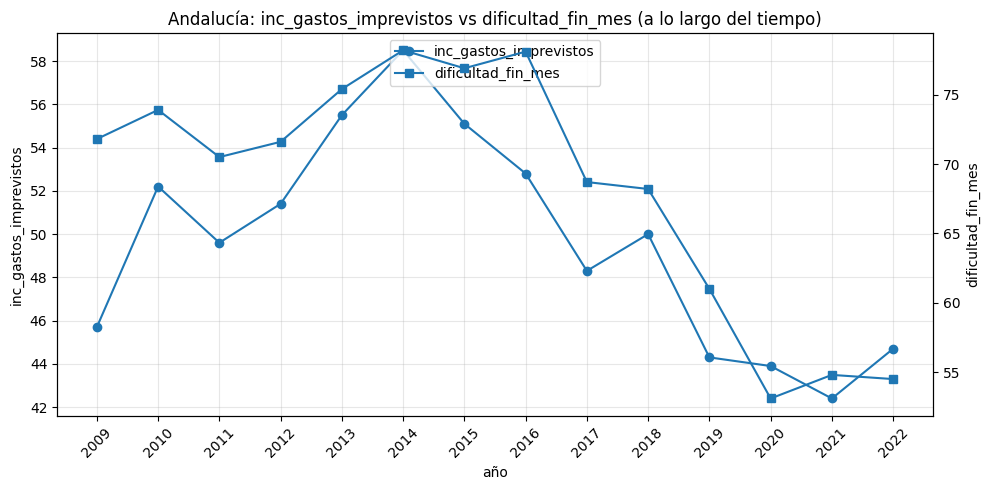

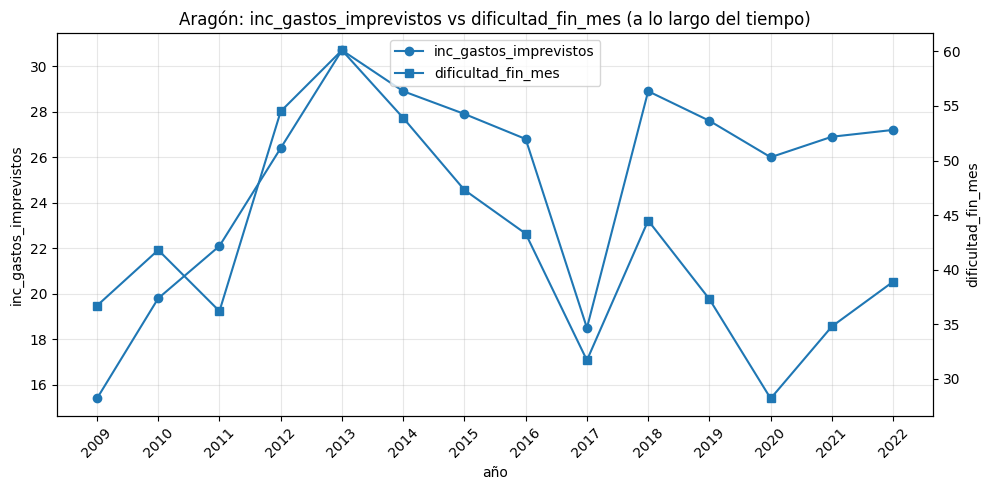

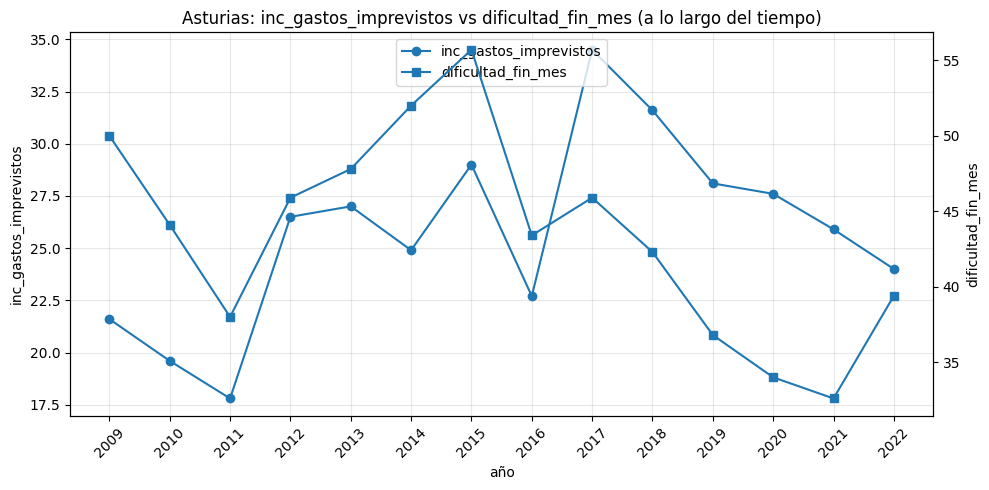

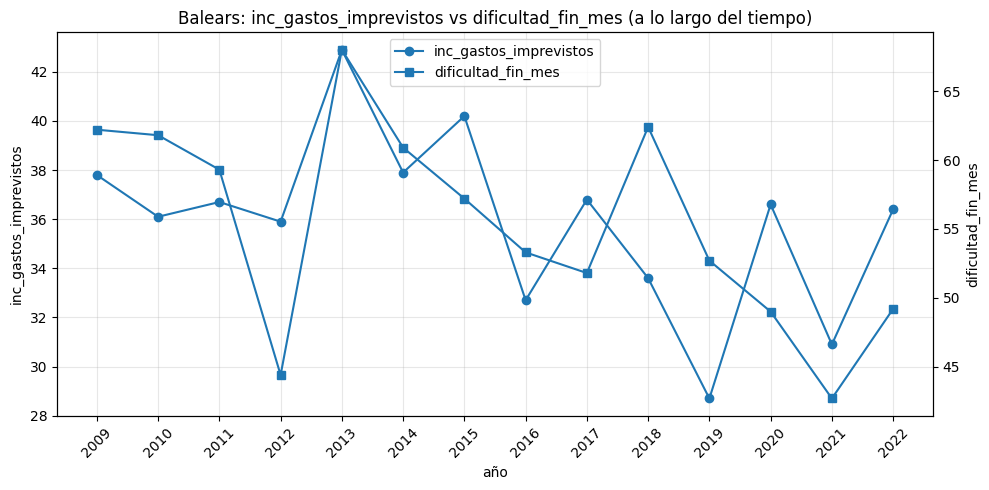

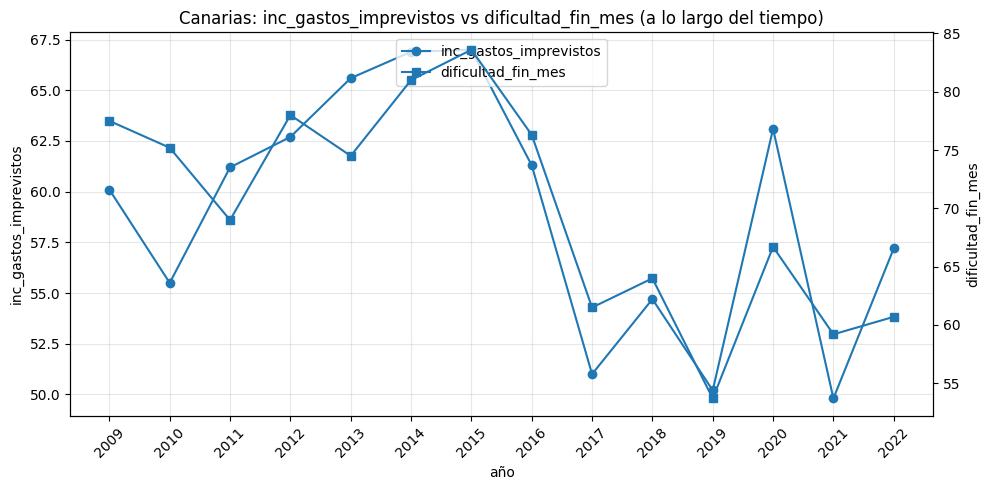

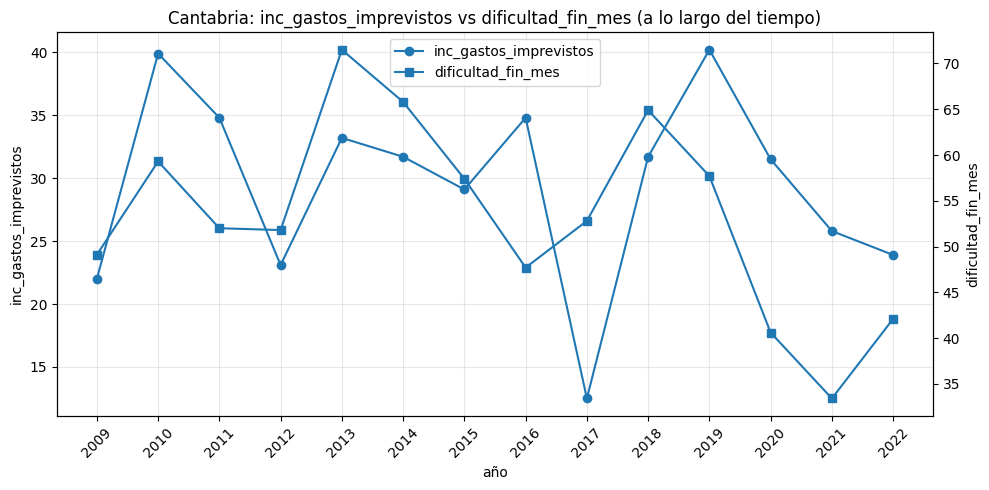

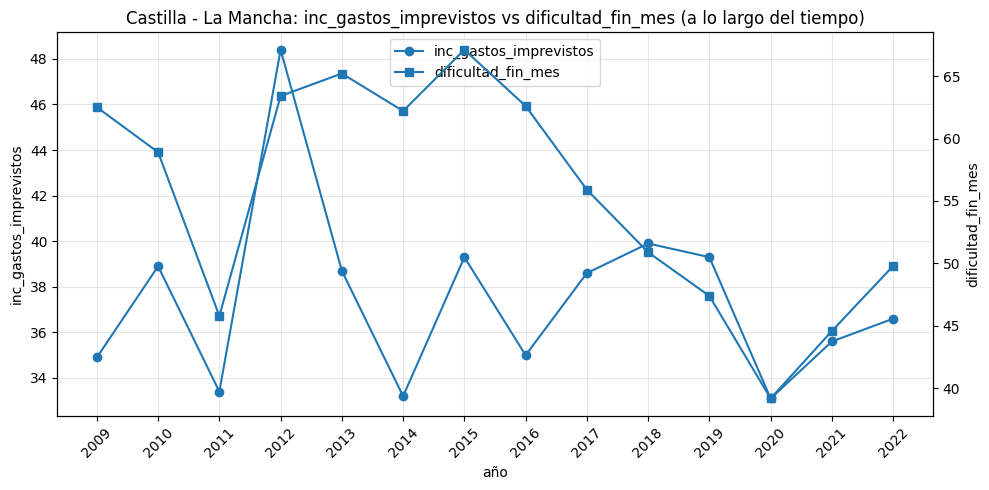

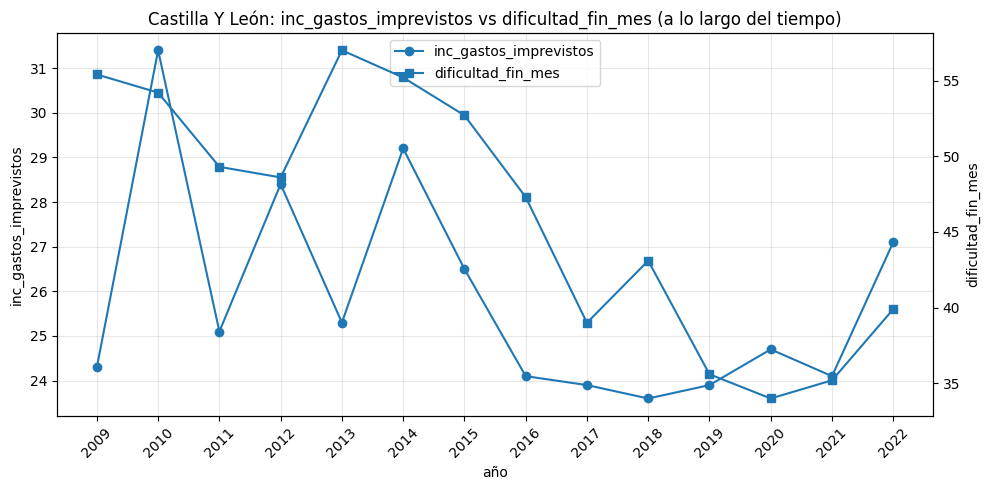

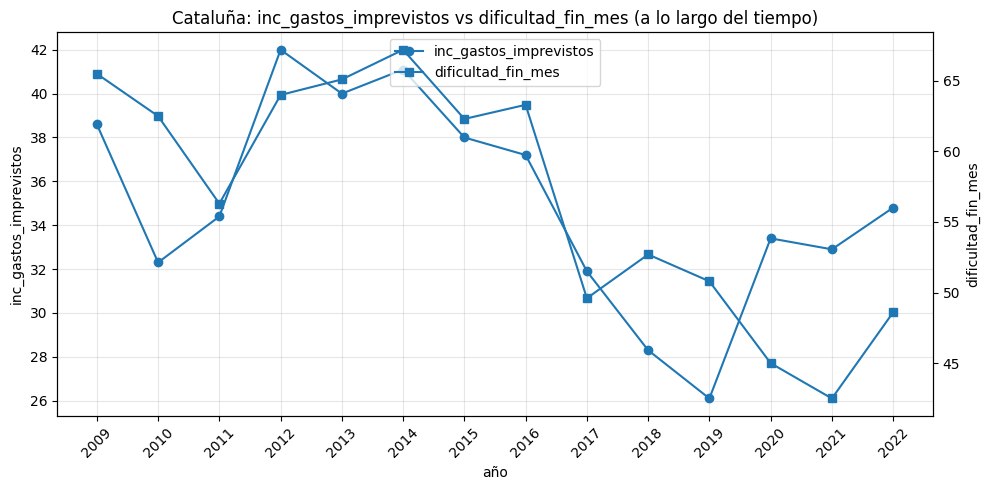

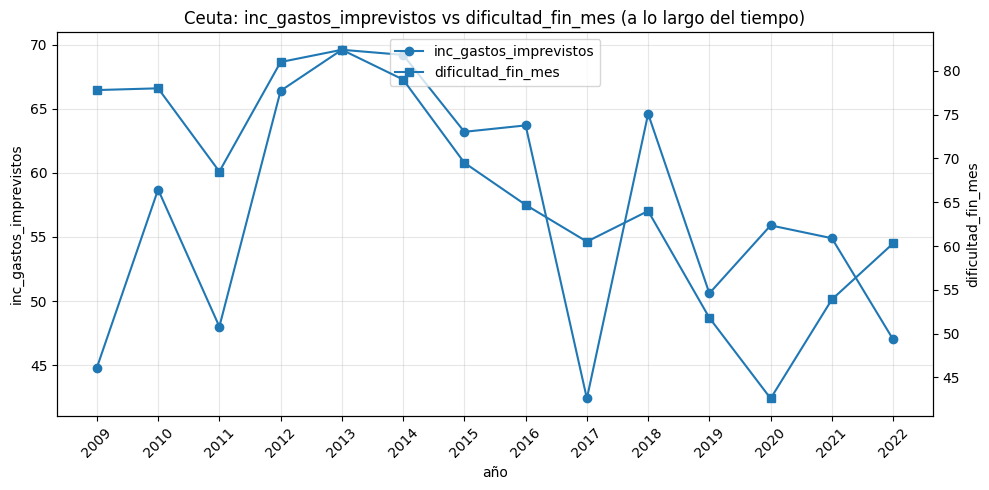

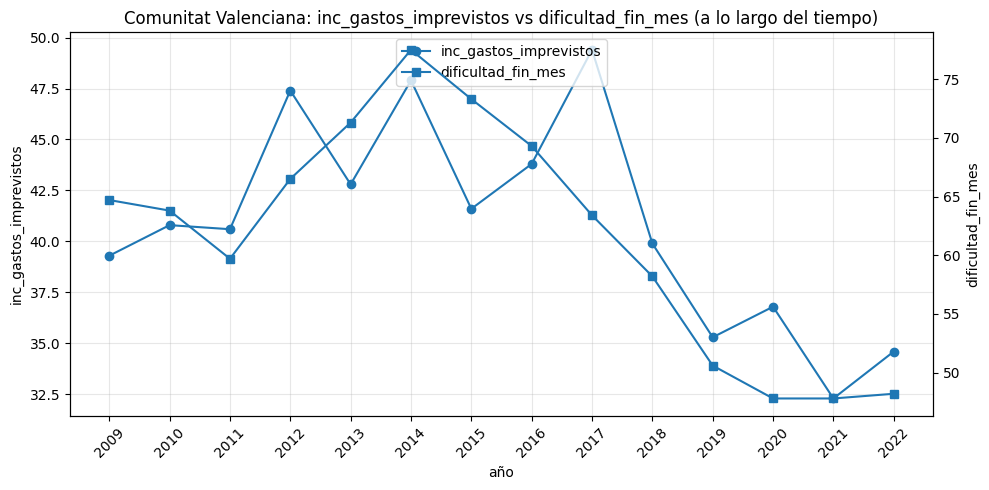

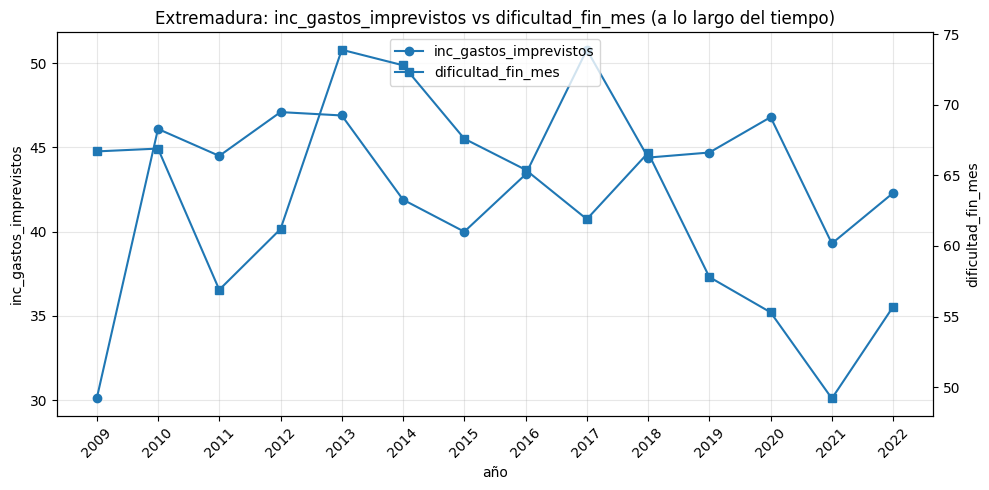

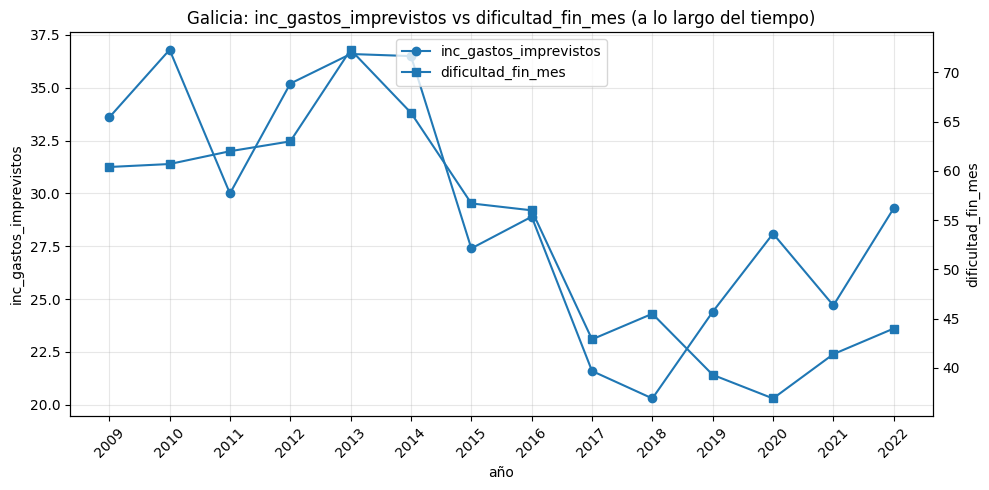

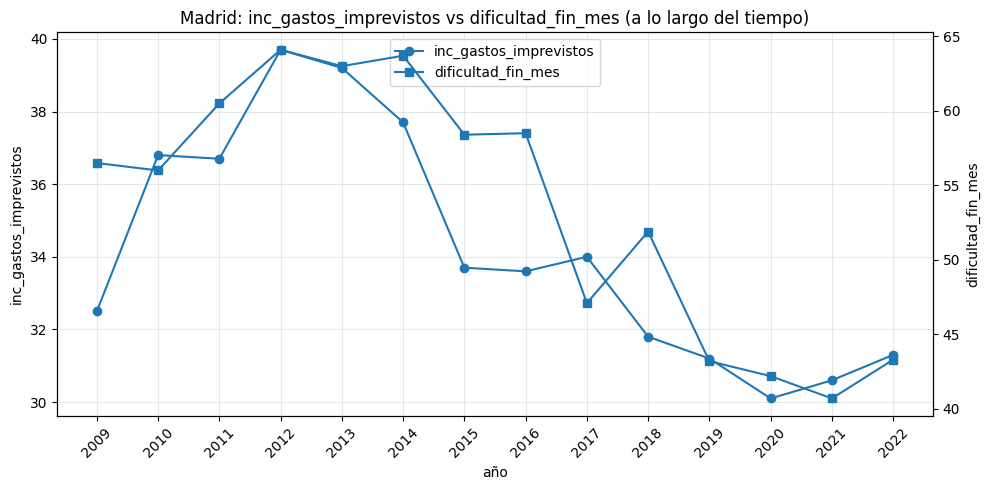

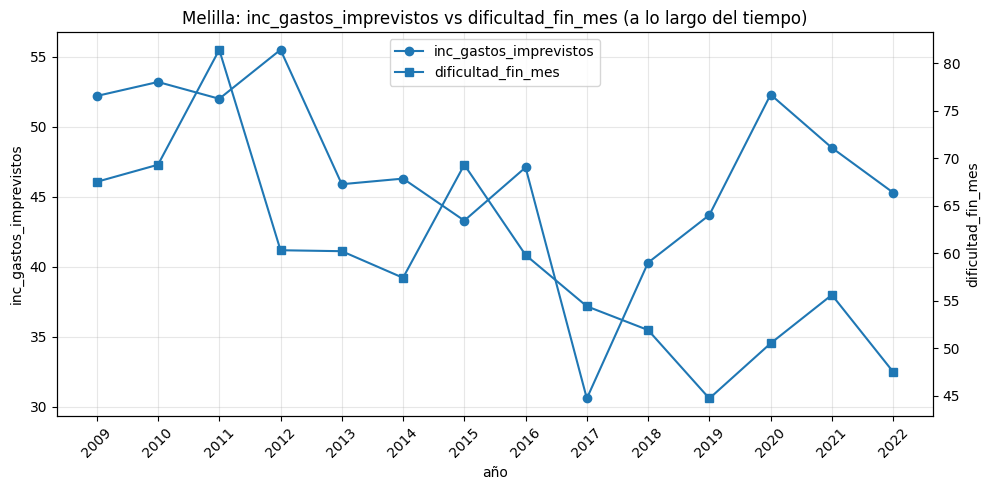

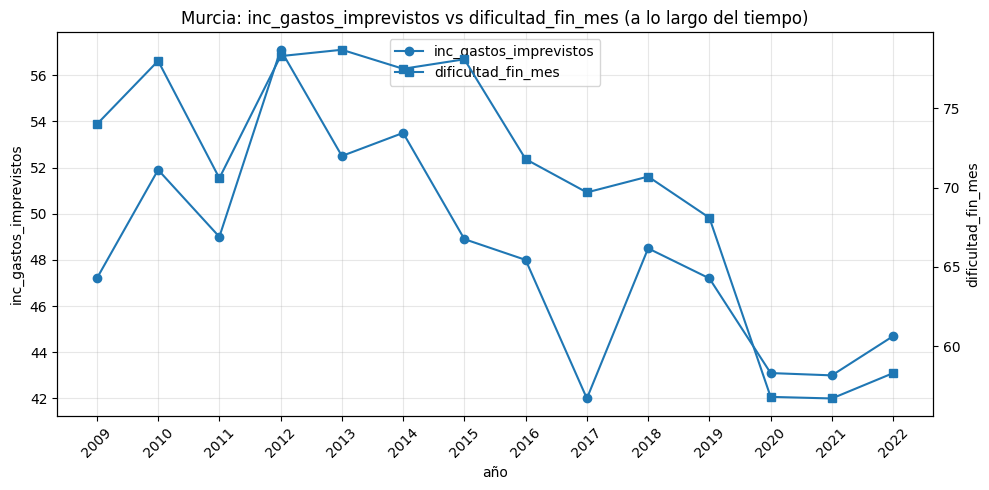

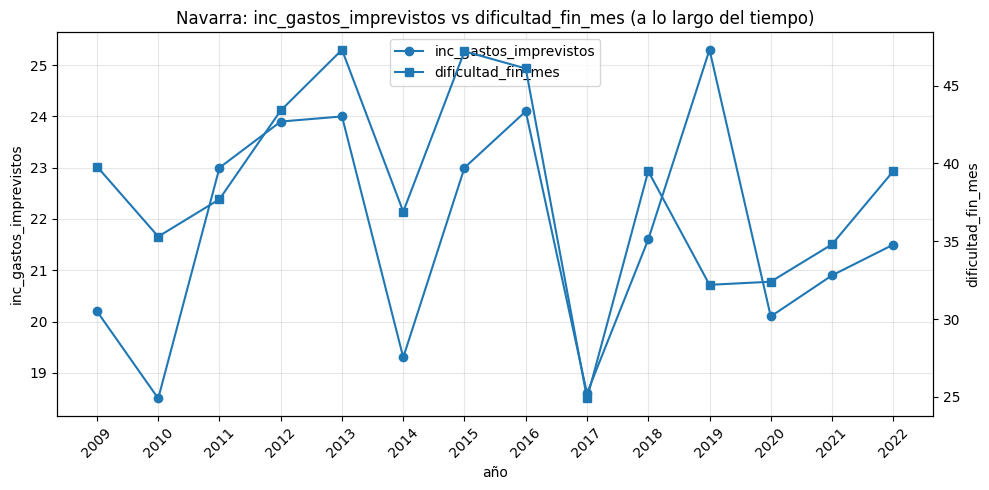

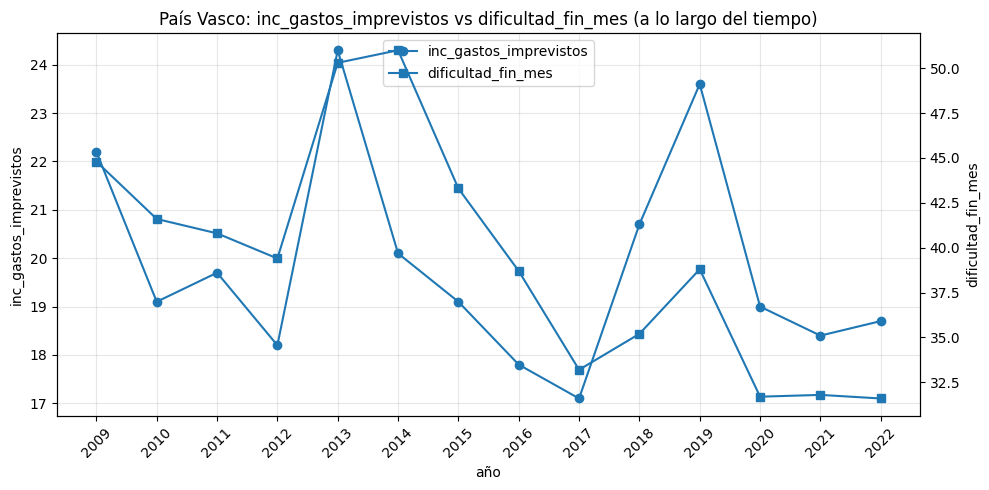

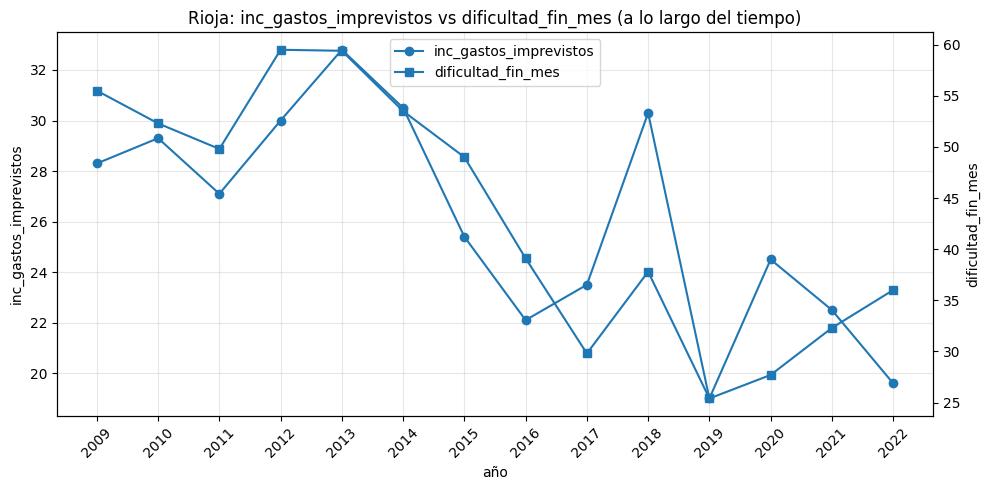

In [15]:
ut.plot_dual_axis(df, comunidades, 'inc_gastos_imprevistos', 'dificultad_fin_mes', x="año")